# IMDb Movie Review Dataset – Data Loading and Exploratory Data Analysis (EDA)

Course: Natural Language Processing

Project: Sentiment Analysis using Machine Learning

Member: Omaya Nayagara

Task: Dataset Loading and Exploratory Data Analysis

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/imdb.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [7]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(418)

In [10]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [11]:
print(df["review"][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [12]:
import matplotlib.pyplot as plt

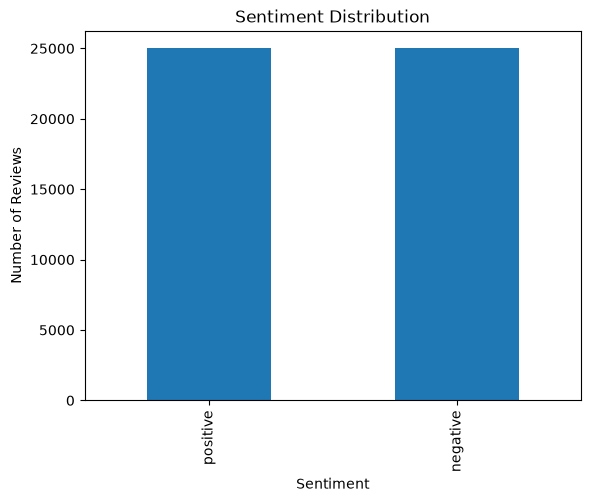

In [13]:
df["sentiment"].value_counts().plot(
    kind="bar",
    title="Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [14]:
df["review_length"] = df["review"].apply(len)

In [15]:
df[["review", "review_length"]].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,1761
1,A wonderful little production. <br /><br />The...,998
2,I thought this was a wonderful way to spend ti...,926
3,Basically there's a family where a little boy ...,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317


In [16]:
df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

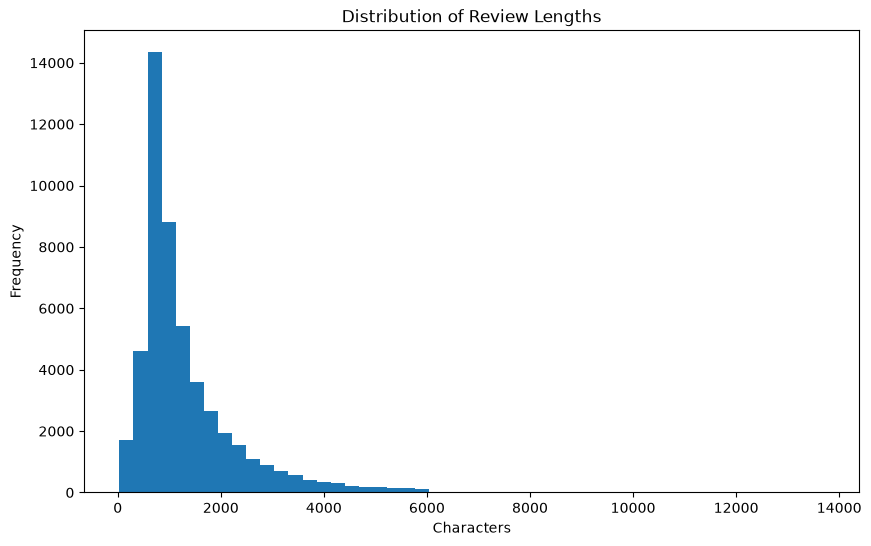

In [17]:
plt.figure(figsize=(10,6))

plt.hist(df["review_length"], bins=50)

plt.title("Distribution of Review Lengths")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [18]:
longest = df["review_length"].idxmax()

print(df["review"][longest])

Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to help his brother, but the referee restrained him while Benoit and Guerrero ganged up on him in the corner. With Benoit stomping away on Bubba, Guerrero set up a table outside. Spike dashed into the ring and somersaulted over the top rope onto Guerrero on the outside! After recovering and taking care of Spike, Guerrero slipped a table into the ring and helped the Wolverine set it up. The tandem then set up for a double superplex from the middle rope which would have put Bubba through the table, but

In [19]:
shortest = df["review_length"].idxmin()

print(df["review"][shortest])

Read the book, forget the movie!


In [20]:
df.groupby("sentiment")["review_length"].mean()

sentiment
negative    1294.06436
positive    1324.79768
Name: review_length, dtype: float64

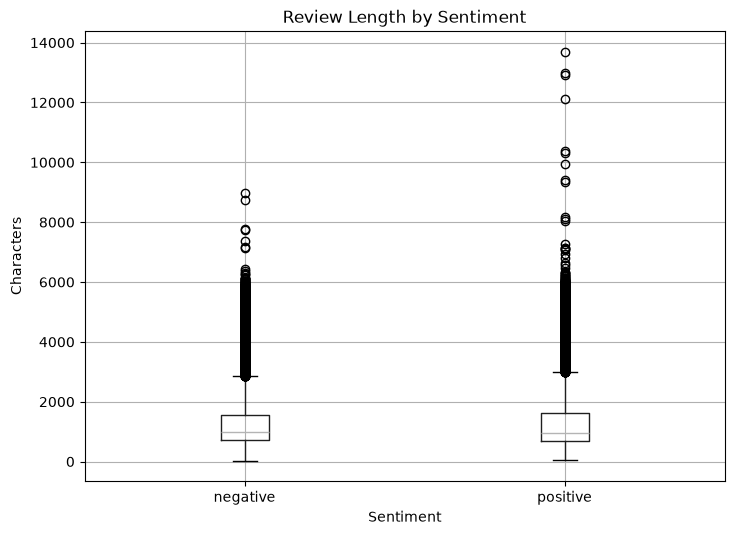

In [21]:
df.boxplot(column="review_length", by="sentiment", figsize=(8,6))

plt.title("Review Length by Sentiment")

plt.suptitle("")

plt.xlabel("Sentiment")

plt.ylabel("Characters")

plt.show()

### Observations

- The dataset contains 50,000 movie reviews.
- There are 2 columns: review and sentiment.
- No missing values were found.
- The dataset contains duplicate reviews, which may be handled during preprocessing.
- The dataset is balanced with equal numbers of positive and negative reviews.
- Reviews contain HTML tags, punctuation, uppercase letters, and other unnecessary characters that require preprocessing before machine learning.

In [1]:
import sys
sys.path.append("../src")

from preprocessing import preprocess

In [2]:
test_df = df.head(100).copy()

test_df["clean_review"] = test_df["review"].apply(preprocess)

test_df.head()

NameError: name 'df' is not defined

In [6]:
try:
    print(preprocess("This movie was AMAZING! <br /> I loved it."))
except Exception as e:
    import traceback
    traceback.print_exc()

Traceback (most recent call last):
  File "C:\Users\Asus\AppData\Local\Temp\ipykernel_8568\509897595.py", line 2, in <module>
    print(preprocess("This movie was AMAZING! <br /> I loved it."))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\notebooks\../src\preprocessing.py", line 76, in preprocess
    tokens = tokenize_text(text)
             ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\notebooks\../src\preprocessing.py", line 44, in tokenize_text
    return word_tokenize(text)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\venv\Lib\site-packages\nltk\tokenize\__init__.py", line 142, in word_tokenize
    sentences = [text] if preserve_line else sent_tokenize(text, language)
                                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\venv\Lib\site-packages\nltk\tokenize\__init__.py", line 119, in sent_tokenize
    tokenizer = _get_punkt_tokenizer(languag

In [3]:
import pandas as pd

df = pd.read_csv("../data/imdb.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
import sys

sys.path.append("../src")

from preprocessing import preprocess

In [5]:
test_df = df.head(100).copy()

test_df["clean_review"] = test_df["review"].apply(preprocess)

test_df.head()

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\Asus/nltk_data'
    - 'c:\\Users\\Asus\\NLP_Group_19\\venv\\nltk_data'
    - 'c:\\Users\\Asus\\NLP_Group_19\\venv\\share\\nltk_data'
    - 'c:\\Users\\Asus\\NLP_Group_19\\venv\\lib\\nltk_data'
    - 'C:\\Users\\Asus\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [7]:
import traceback

try:
    print(preprocess("This movie was AMAZING!!! <br /> I loved it."))
except Exception:
    traceback.print_exc(limit=None)

Traceback (most recent call last):
  File "C:\Users\Asus\AppData\Local\Temp\ipykernel_8568\159811013.py", line 4, in <module>
    print(preprocess("This movie was AMAZING!!! <br /> I loved it."))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\notebooks\../src\preprocessing.py", line 76, in preprocess
    tokens = tokenize_text(text)
             ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\notebooks\../src\preprocessing.py", line 44, in tokenize_text
    return word_tokenize(text)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\venv\Lib\site-packages\nltk\tokenize\__init__.py", line 142, in word_tokenize
    sentences = [text] if preserve_line else sent_tokenize(text, language)
                                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\NLP_Group_19\venv\Lib\site-packages\nltk\tokenize\__init__.py", line 119, in sent_tokenize
    tokenizer = _get_punkt_tokenizer(lan

In [8]:
import nltk
print(nltk.__version__)

3.10.0


In [9]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
import nltk

resources = {
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
    "stopwords": "corpora/stopwords",
    "wordnet": "corpora/wordnet",
}

for name, path in resources.items():
    try:
        nltk.data.find(path)
        print(f"{name}: ✅ Available")
    except LookupError:
        print(f"{name}: ❌ Missing")

punkt: ✅ Available
punkt_tab: ✅ Available
stopwords: ✅ Available
wordnet: ✅ Available


# Text Preprocessing

In [11]:
import sys
import os

sys.path.append("../src")

from preprocessing import preprocess

In [12]:
import pandas as pd

df = pd.read_csv("../data/imdb.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
test_df = df.head(100).copy()

test_df["clean_review"] = test_df["review"].apply(preprocess)

test_df.head()

OSError: No such file or directory: 'C:\\Users\\Asus\\AppData\\Roaming\\nltk_data\\corpora\\wordnet\\lexnames'

In [16]:
import nltk

nltk.download("wordnet")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...


True

In [17]:
from nltk.corpus import wordnet

print(wordnet.synsets("good")[:5])

[Synset('good.n.01'), Synset('good.n.02'), Synset('good.n.03'), Synset('commodity.n.01'), Synset('good.a.01')]


In [1]:
import pandas as pd

df = pd.read_csv("../data/imdb.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
import sys
sys.path.append("../src")

from preprocessing import preprocess

In [3]:
test_df = df.head(100).copy()

test_df["clean_review"] = test_df["review"].apply(preprocess)

test_df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [4]:
df.shape

(50000, 2)

In [5]:
df["clean_review"] = df["review"].apply(preprocess)

In [6]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [7]:
df["clean_review"].isnull().sum()

np.int64(0)

In [8]:
(df["clean_review"] == "").sum()

np.int64(0)

In [ ]:
df.to_csv("../data/imdb_cleaned.csv", index=False)

: 